In [579]:

import os
import yaml
from copy import deepcopy
from functools import partial
from pprint import pprint
from typing import Optional,Literal

import numpy as np
import pandas as pd
import pyreadr as pyr

import matplotlib.pyplot as plt
import seaborn as sns

import optuna

from sklearn.model_selection import cross_validate, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import make_scorer, r2_score, root_mean_squared_error, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from IPython.display import clear_output

In [580]:

train:pd.DataFrame = pyr.read_r('datasets/train.rds')[None]
rs_seed=1
prof_qmd = True

In [581]:
def ParamXGB(trial):
    '''
    Hyperparameters Search Method for Optuna - XGB model
    '''
    params = {
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 400, 1200, step=10),
        "Model__learning_rate": trial.suggest_float("Model__learning_rate", 0.01, 0.2, step=0.002),
        "Model__max_depth": trial.suggest_int("Model__max_depth", 2, 8),
        "Model__subsample": trial.suggest_float("Model__subsample", 0.5, 1.0),
        "Model__colsample_bytree": trial.suggest_float("Model__colsample_bytree", 0.5, 1.0),
        "Model__reg_lambda": trial.suggest_float("Model__reg_lambda", 1e-3, 10, log=True),# log-scaled
        "Model__reg_alpha": trial.suggest_float("Model__reg_alpha", 1e-3, 10, log=True),# log-scaled
        "Model__min_child_weight": trial.suggest_int("Model__min_child_weight", 2, 8),
        "Model__gamma": trial.suggest_float("Model__gamma", 0.0, 5.0),
        "Model__grow_policy": trial.suggest_categorical("Model__grow_policy", ["lossguide", "depthwise"]),
    }
    return params



def ParamRF(trial):
    '''
    Hyperparameters Search Method for Optuna - Random Forest model
    '''
    params = {
        "Model__n_estimators": trial.suggest_int("Model__n_estimators", 200, 1200, step=20),
        "Model__max_depth": trial.suggest_categorical(
            "Model__max_depth", [None] + list(range(3, 9))
        ),
        "Model__min_samples_split": trial.suggest_int("Model__min_samples_split", 2, 20),
        "Model__min_samples_leaf": trial.suggest_int("Model__min_samples_leaf", 8, 15),
        "Model__max_features": trial.suggest_categorical("Model__max_features", ["sqrt", 0.3, 1.0]),
        "Model__max_leaf_nodes": trial.suggest_categorical(
            "Model__max_leaf_nodes", [None] + list(range(40, 201, 5))
        ),
        "Model__min_impurity_decrease": trial.suggest_float(
            "Model__min_impurity_decrease", 0.0, 1e-8
        ),
        "Model__ccp_alpha": trial.suggest_float("Model__ccp_alpha", 0.0, 0.02),
    }

    return params


def ParamDTR(trial):
    '''
    Hyperparameters Search Method for Optuna - Decision Tree Regressor model
    '''
    params = {
        "Model__criterion": trial.suggest_categorical(
            "Model__criterion", ["squared_error", "friedman_mse"]
        ),
        "Model__max_depth": trial.suggest_int("Model__max_depth", 6, 25),
        "Model__min_samples_split": trial.suggest_int("Model__min_samples_split", 5, 25),
        "Model__min_samples_leaf": trial.suggest_int("Model__min_samples_leaf", 5, 18),
        "Model__max_features": trial.suggest_categorical(
            "Model__max_features", ["sqrt", 0.3, 0.5, 0.7, 1.0]
        ),
        "Model__ccp_alpha": trial.suggest_float("Model__ccp_alpha", 0.0, 0.05),
        "Model__min_impurity_decrease": trial.suggest_float("Model__min_impurity_decrease", 0.0, 0.01),
    }
    return params


In [ ]:
class YMLstudy():
    '''
    Homemade Class for to save studies as YML file.
    Display and save Optuna Studies in the folder optuna-study. It creates one if does not exist
    Parameters
    ----------
    model [str]: name of model you are working on

    Returns
    ----------
    None
    '''
    
    def __init__(self, model:str):

        os.makedirs("optuna-study", exist_ok=True)

        self.model = model
        self.file_name = f'{model}-opt_parm.yml'
        self.location = f'optuna-study/{self.file_name}'
        
        if os.path.isfile(self.location):
            self._get_vals()
    
    def read(self, what:Optional[str] = None):

            if what in ['all', None]:
                return self.best_all 
            else:
                return self.best_all[what]


    def write_study(self, study: optuna.Study):
        """
        Save only best_trials to YAML file
        or the efficient frontier in case of multi-optim
        """
        with open(self.location, "w") as writer:
            pareto_data = []
            for t in study.best_trials:
                pareto_data.append({
                    "trial_number": t.number,
                    "values": [round(v, 4) for v in (
                        t.values if isinstance(t.values, (list, tuple)) else [t.value]
                    )],
                    "params": t.params,
                })

            yaml.safe_dump(
                {"best_trials": pareto_data},
                writer,
                default_flow_style=False,
                sort_keys=False,
            )

        self._get_vals()


    def _get_vals(self):
        """
        Load the first best trial from YAML (for quick access).
        Used internally
        """
        with open(self.location, "r") as loader:
            out = yaml.safe_load(loader)
            self.best_all = out

            # Use only the first best trial
            first_trial = out["best_trials"][0] if out.get("best_trials") else None
            if first_trial:
                self.best_idx = first_trial["trial_number"]
                self.best_parameters = first_trial["params"]
                self.results = first_trial["values"]


def Search(model:Literal['RF', 'DTR', 'XGB'],
           df:pd.DataFrame,
           scores = {
                "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
            },
            directions:list[str] = ['minimize'],
            scale:bool=False,
            minimize_gap:bool = True,
            trials:int=1000,
            rs_seed:int=1) -> optuna.study.Study:
            """
            It does Optuna hyperparameter search with preprocessing and cross-validation.
            I added multi-objective tuning, In our case minimize RMSE and GAP. 

            Optional Scaler, optional scaling. Uses YMLstudy to save best trials

            Parameters
            ----------
            model : str
                Model name ('RF', 'DTR', or 'XGB').
            df : pd.DataFrame
                Input data with features and target column 'score'.
            scores : dict, optional
                Custom scikit-learn scoring dictionary (default: RMSE).
            directions : list[str], optional
                Optimization direction(s). Default: ['minimize'].
            scale : bool, default=False
                Whether to scale numeric features.
            minimize_gap : bool, default=True
                If True, adds a second objective to minimize train–test RMSE gap.
            trials : int, default=1000
                Number of Optuna trials.
            rs_seed : int, default=1

            Returns
            -------
            study : optuna.study.Study
                The completed Optuna study object.
            """
            ml_model,parameters = _modelSelection(model)

            X = deepcopy(df.drop(columns=["score"]))
            y = deepcopy(df["score"])

            cats = X.select_dtypes(include=["object", "category"]).columns.tolist()
            nums = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

            preprocessor = ColumnTransformer([
                ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cats),
                ("numeric", StandardScaler() if scale else "passthrough", nums)
            ])

            pipeline = Pipeline([
                ("preprocessor", preprocessor),
                ("Model", ml_model)
            ])
            ### I need to fix X
            yml = YMLstudy(model)

            study = optuna.create_study(
                    study_name=f"{model}_score",
                    storage="sqlite:///optuna-study/optuna-study.db",
                    directions=directions+(['minimize'] if minimize_gap else []), # multi-objective
                    load_if_exists=True
                )
            objF = partial(OptunaObj,
                        data = (X,y),
                        pipe = pipeline,
                        scores=scores,
                        param=parameters,
                        min_gap = minimize_gap)
            
            study.optimize(objF, n_trials=trials)

            clear_output()

            yml.write_study(study)

            return study

def OptunaObj(
        trial,
        data:tuple,
        pipe:Pipeline,
        scores:dict,
        min_gap:bool,
        param,
        rs_seed:int=1):
    
    '''
    Objective Function for Optuna -> find the hyper parameters that minimize the return
    '''
    
    x,y=data
    print(scores)
    pipe.set_params(**param(trial))

    res = cross_validate(
        estimator=pipe,
        X=x,
        y=y,
        cv=KFold(n_splits=8, shuffle=True, random_state=rs_seed),
        scoring=scores,
        n_jobs=-1,
        verbose=0,
        return_train_score=min_gap
    )
    rmse_fix = -res["test_RMSE"]
    rmse, rmse_std = np.mean(rmse_fix), np.std(rmse_fix) #becase cross_validate
    if min_gap:
        gaps = abs((-res["train_RMSE"])-rmse_fix)
        mean_gap, std_gap = np.mean(gaps), np.std(gaps)
        return rmse+0.5*rmse_std, mean_gap+0.5*std_gap
    else:
        return rmse


def _modelSelection(model):

    match model:

        case 'RF':
            ml_model = RandomForestRegressor(bootstrap=True,
                            criterion='squared_error',
                            random_state=rs_seed)
            parameters = ParamRF
        case 'DTR':
            ml_model = DecisionTreeRegressor(splitter="best",
                            max_leaf_nodes=None,
                            random_state=rs_seed)
            parameters = ParamDTR

        case 'XGB':
            ml_model = XGBRegressor(random_state=rs_seed)
            parameters = ParamXGB

    return ml_model,parameters


def TestModel(
        model:str,
        study_param:dict,
        df:pd.DataFrame,
        scale:bool=False,
        scores:dict = {
                "RMSE": make_scorer(root_mean_squared_error, greater_is_better=False),
                "MSE": make_scorer(mean_squared_error, greater_is_better=False),
                "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
                "R2": make_scorer(r2_score, greater_is_better=True),

            },
        cross_val:bool = True,
        k_splits:int = 5):

    print(f'\n\nUsing best parameter from optuna study:')
    pprint(study_param)

    ml_model,_ = _modelSelection(model)

    X = deepcopy(df.drop(columns=["score"]))
    y = deepcopy(df["score"])

    cats = X.select_dtypes(include=["object", "category"]).columns.tolist()
    nums = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

    preprocessor = ColumnTransformer([
        ("categorical", OneHotEncoder(sparse_output=False, handle_unknown="ignore"), cats),
        ("numeric", StandardScaler() if scale else "passthrough", nums)
    ])

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("Model", ml_model)
    ]).set_params(**study_param)

    if cross_val:
        cv = cross_validate(
            estimator=pipeline,
            X=X,
            y=y,
            cv=KFold(n_splits=k_splits, shuffle=True, random_state=rs_seed),
            scoring=scores,
            n_jobs=-1,
            verbose=0,
            return_train_score=True
        )

        train_rmse = -cv["train_RMSE"]
        test_rmse = -cv["test_RMSE"]
        gap = abs(train_rmse - test_rmse)


        output = pd.DataFrame(cv).abs().assign(
            model = model,
            gap = gap)
        
        return output
    else:
        model = pipeline.fit(X,y)

        return model
    

def cv_boxplot(concatenated: pd.DataFrame):
    """
    Creates 6 minimalist boxplots (3 models × [test_RMSE, test_R2])
    with numeric y-axis labels only on the leftmost column.
    """

    metrics = ["test_RMSE", "test_R2", 'gap',]
    models = concatenated["model"].unique()
    fig, axes = plt.subplots(len(metrics), len(models), figsize=(9, 7), sharey="row")

    for row, metric in enumerate(metrics):
        for col, model in enumerate(models):
            ax = axes[row, col]
            data = concatenated.loc[concatenated["model"] == model, metric]

            # --- Boxplot ---
            ax.boxplot(
                data,
                vert=True,
                widths=0.35,
                patch_artist=True,
                boxprops=dict(facecolor="0.9", color="black", linewidth=0.9),
                medianprops=dict(color="black", linewidth=1.3),
                whiskerprops=dict(color="black", linewidth=0.9),
                capprops=dict(color="black", linewidth=0.9),
                flierprops=dict(marker=".", markersize=4, color="black", alpha=0.5),
            )

            # --- Mean marker only ---
            mean_val = np.mean(data)
            ax.plot(1, mean_val, "o", color="black", markersize=5)

            # --- Spines and ticks ---
            for spine in ["top", "right"]:
                ax.spines[spine].set_visible(False)
            ax.spines["bottom"].set_linewidth(0.8)
            ax.spines["left"].set_visible(col == 0)
            ax.spines["left"].set_linewidth(0.8 if col == 0 else 0)

            # X-axis cleanup
            ax.tick_params(axis="x", bottom=False, labelbottom=False)

            # Y-axis only on leftmost column
            if col == 0:
                ax.tick_params(axis="y", labelsize=8, width=0.6)
                ax.set_ylabel(metric.replace("_", " "), fontsize=9, labelpad=8)
            else:
                ax.tick_params(axis="y", left=False, labelleft=False)

            ax.set_title(model, fontsize=9, pad=3)

    plt.suptitle("Cross-Validation RMSE and R2 per Model", fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()
    if not prof_qmd:
        plt.savefig('charts/CV_bbox.png')

def plot_gap_rmse(df: pd.DataFrame):
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        data=df,
        x="gap", y="test_RMSE",
        hue="model", s=70, alpha=0.8,
        edgecolor="black", linewidth=0.6
    )

    plt.title("Stability vs Accuracy: Gap vs Test RMSE", fontsize=11)
    plt.xlabel("|Train–Test| RMSE Gap")
    plt.ylabel("Test RMSE")
    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()
    if not prof_qmd:
        plt.savefig('charts/gap_accuracy_test.png')

def plot_overfitting(concatenated: pd.DataFrame):
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        data=concatenated,
        x="train_RMSE", y="test_RMSE",
        hue="model", style="model",
        s=70, alpha=0.8, edgecolor="black", linewidth=0.6
    )

    l = concatenated[["train_RMSE","test_RMSE"]].min().min()
    m = concatenated[["train_RMSE","test_RMSE"]].max().max()
    plt.plot([l, m], [l, m], 'k--', lw=1, label="Perfect Generalization") # train==test

    plt.title("Bias–Variance Check: Train vs Test RMSE (8-fold CV)", fontsize=11)
    plt.xlabel("Train RMSE")
    plt.ylabel("Test RMSE")
    plt.legend(frameon=False)
    sns.despine()
    plt.tight_layout()
    plt.show()
    if not prof_qmd:
        plt.savefig('charts/overfitting.png')

def cv_sum_bars(summ_table: pd.DataFrame):
    metrics = ["test_RMSE", 'test_MSE', 'test_MAE',"test_R2", "gap"]
    fig, axes = plt.subplots(1, len(metrics), figsize=(10, 4))

    for i, metric in enumerate(metrics):
        ax = axes[i]
        means = summ_table[f"mean_{metric}"]
        stds = summ_table[f"std_{metric}"]

        ax.bar(
            summ_table["model"],
            means,
            yerr=stds,
            capsize=4,
            color="0.8",
            edgecolor="black",
            linewidth=0.9
        )
        # ax.set_ylim(bottom=-0.05)
        ax.set_title(metric.replace("_", " "), fontsize=10, pad=5)


    plt.suptitle("Cross-Validation Mean w/ Std per Model", fontsize=11)
    plt.tight_layout()
    plt.show()
    if not prof_qmd:
        plt.savefig('charts/cv_bars.png')

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 117)

In [ ]:
rf=Search('RF',train,trials=1) #uncompleted

In [ ]:
if not prof_qmd:
    xgb=Search('XGB',train,trials=2000)
    dtr=Search('DTR',train,trials=2000)
    rf=Search('RF',train,trials=2000) #uncompleted

if prof_qmd:
       
       xgb = {'Model__n_estimators': 740,
                'Model__learning_rate': 0.16,
                'Model__max_depth': 4,
                'Model__subsample': 0.5552997171468768,
                'Model__colsample_bytree': 0.9815919085306092,
                'Model__reg_lambda': 0.24481085805808236,
                'Model__reg_alpha': 3.7839122777002308,
                'Model__min_child_weight': 5,
                'Model__gamma': 2.5266054240330855,
                'Model__grow_policy': 'lossguide'}
       
       dtr = {'Model__criterion': 'friedman_mse',
                'Model__max_depth': 9,
                'Model__min_samples_split': 18,
                'Model__min_samples_leaf': 6,
                'Model__max_features': 0.5,
                'Model__ccp_alpha': 0.019465532586941975,
                'Model__min_impurity_decrease': 0.008663363461552305}
       
       rf = {'Model__n_estimators': 340,
                'Model__max_depth': 3,
                'Model__min_samples_split': 10,
                'Model__min_samples_leaf': 8,
                'Model__max_features': 1.0,
                'Model__max_leaf_nodes': 75,
                'Model__min_impurity_decrease': 6.6086975206585986e-09,
                'Model__ccp_alpha': 0.018485648158400047}

In [ ]:
k = 8
xgb_fin = TestModel('XGB',
          study_param = xgb if prof_qmd else xgb.best_trials[0].params,
          df=train,
          k_splits=k)

dtr_fin = TestModel('DTR',
          study_param = dtr if prof_qmd else dtr.best_trials[0].params,
          df=train,
          k_splits=k)

rf_fin = TestModel('RF',
          study_param = rf if prof_qmd else rf.best_trials[0].params,
          df=train,
          k_splits=k)

concatenated = pd.concat([dtr_fin,xgb_fin,rf_fin],axis=0).reset_index(drop=True)





Using best parameter from optuna study:
{'Model__colsample_bytree': 0.9815919085306092,
 'Model__gamma': 2.5266054240330855,
 'Model__grow_policy': 'lossguide',
 'Model__learning_rate': 0.16,
 'Model__max_depth': 4,
 'Model__min_child_weight': 5,
 'Model__n_estimators': 740,
 'Model__reg_alpha': 3.7839122777002308,
 'Model__reg_lambda': 0.24481085805808236,
 'Model__subsample': 0.5552997171468768}


Using best parameter from optuna study:
{'Model__ccp_alpha': 0.019465532586941975,
 'Model__criterion': 'friedman_mse',
 'Model__max_depth': 9,
 'Model__max_features': 0.5,
 'Model__min_impurity_decrease': 0.008663363461552305,
 'Model__min_samples_leaf': 6,
 'Model__min_samples_split': 18}


Using best parameter from optuna study:
{'Model__ccp_alpha': 0.018485648158400047,
 'Model__max_depth': 3,
 'Model__max_features': 1.0,
 'Model__max_leaf_nodes': 75,
 'Model__min_impurity_decrease': 6.6086975206585986e-09,
 'Model__min_samples_leaf': 8,
 'Model__min_samples_split': 10,
 'Model__n_est

In [ ]:
# get results
cols=[col for col in concatenated.columns if col not in ['fit_time','score_time','model']]
summ_table = (concatenated
         .pivot_table(index='model',
                      values=cols,
                      aggfunc=['mean', 'std'])
         .round(4))
summ_table.columns = [f"{s}_{m}" for s,m in summ_table.columns]

summ_table.reset_index(inplace=True)

with pd.ExcelWriter('outputs/cv_results.xlsx') as w:
    summ_table.to_excel(w,sheet_name=f'k_{k}',index=False)

In [ ]:
mean_col = [col for col in summ_table.columns if col.startswith('mean')]
std_col  = [col for col in summ_table.columns if col.startswith('std')]

print('\nSummary of CV: MEAN\n')
display(summ_table[['model']+mean_col])

print('\nSummary of CV: STD\n')
display(summ_table[['model']+std_col])



Summary of CV: MEAN



,model,mean_gap,mean_test_MAE,mean_test_MSE,mean_test_R2,mean_test_RMSE,mean_train_MAE,mean_train_MSE,mean_train_R2,mean_train_RMSE
0,DTR,0.1367,0.7346,0.8681,0.0979,0.9251,0.6435,0.6595,0.3178,0.8118
1,RF,0.1348,0.6766,0.7536,0.2125,0.8600,0.6130,0.6254,0.3540,0.7904
2,XGB,0.1550,0.7052,0.8081,0.1500,0.8933,0.5968,0.5793,0.4010,0.7610



Summary of CV: STD



,model,std_gap,std_test_MAE,std_test_MSE,std_test_R2,std_test_RMSE,std_train_MAE,std_train_MSE,std_train_R2,std_train_RMSE
0,DTR,0.0856,0.1072,0.2268,0.1194,0.1235,0.0204,0.0443,0.0504,0.0272
1,RF,0.0948,0.1107,0.2211,0.1066,0.1324,0.0242,0.0461,0.0355,0.0295
2,XGB,0.0899,0.0819,0.1932,0.0460,0.1122,0.0143,0.0265,0.0266,0.0175


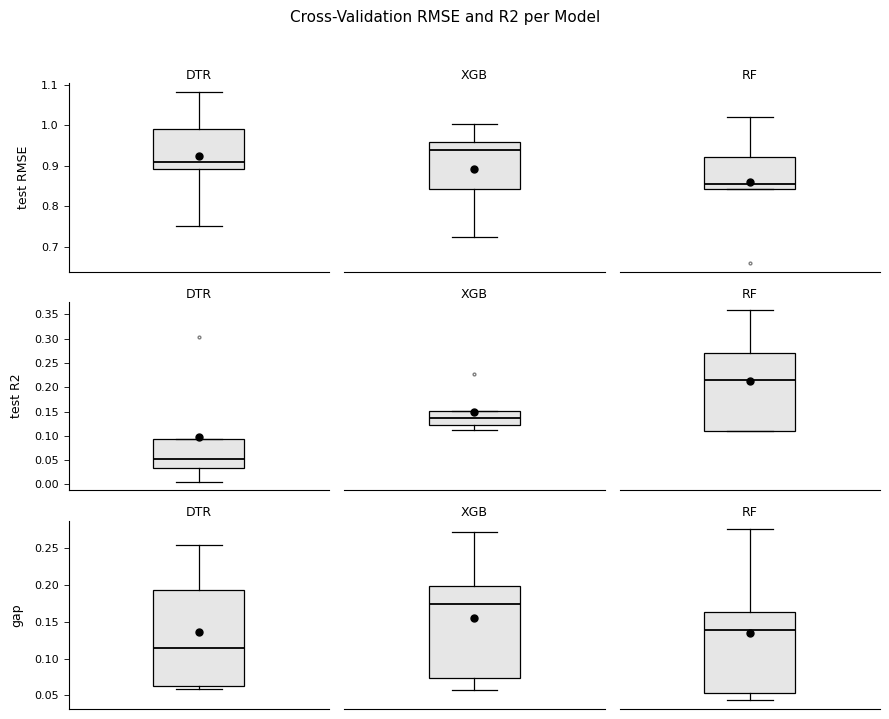

In [ ]:
cv_boxplot(concatenated)

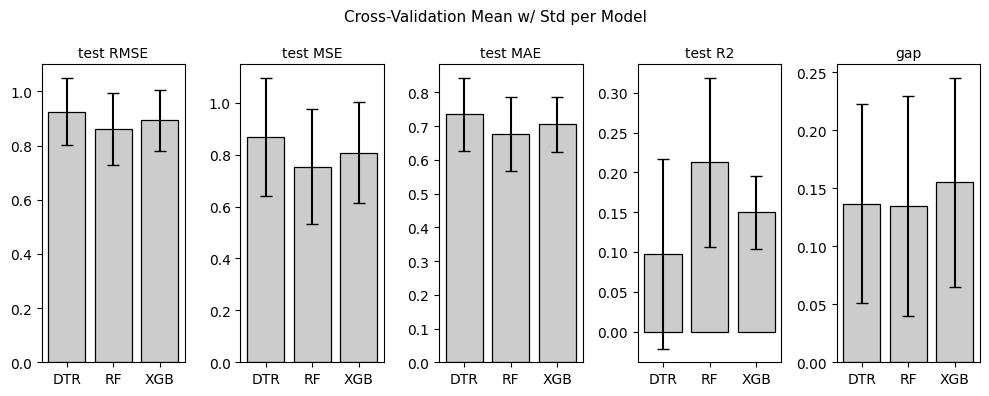

In [ ]:
cv_sum_bars(summ_table)

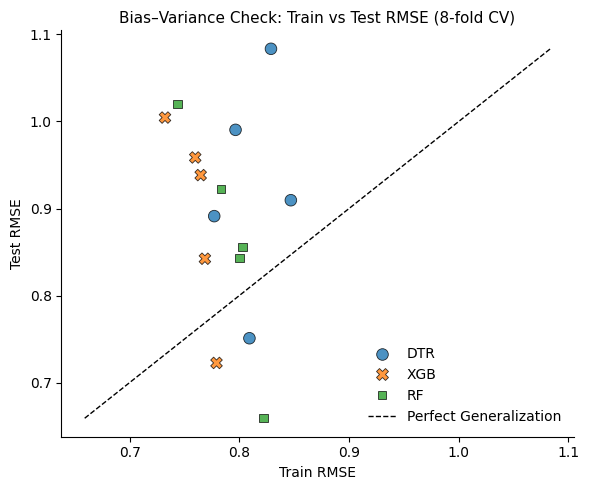

In [ ]:
plot_overfitting(concatenated)


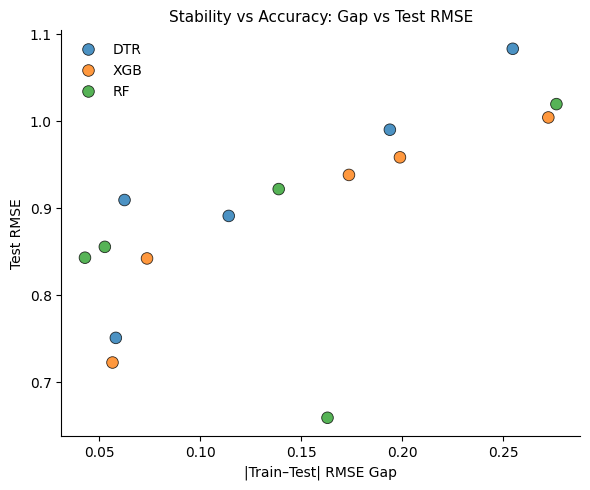

In [ ]:
plot_gap_rmse(concatenated)